# Capstone: 2

## Amazon Reviews Analysis

### Section 1: Data Preprocessing & EDA

In [1]:
# Import Libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("amazon.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
df.shape

(1465, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [5]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [6]:
# Percentage of missing values in each column
missing_values = df.isnull().sum() / len(df) * 100
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

rating_count    0.136519
dtype: float64

In [7]:
# Convert discounted_price
df["discounted_price"] = (
    df["discounted_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Convert actual_price
df["actual_price"] = (
    df["actual_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Convert discount_percentage
df["discount_percentage"] = (
    df["discount_percentage"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

# Convert rating
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

# Convert rating_count
df["rating_count"] = (
    df["rating_count"]
    .str.replace(",", "", regex=False)
)

df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

In [8]:
# Handle missing values

df["review_content"] = df["review_content"].fillna("No Review")

# Fill missing ratings with median
df["rating"] = df["rating"].fillna(df["rating"].median())

# Fill missing discount percentage with median
df["discount_percentage"] = df["discount_percentage"].fillna(df["discount_percentage"].mode()[0])

# Fill rating_count
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].median())

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   str    
 1   product_name         1465 non-null   str    
 2   category             1465 non-null   str    
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1465 non-null   float64
 8   about_product        1465 non-null   str    
 9   user_id              1465 non-null   str    
 10  user_name            1465 non-null   str    
 11  review_id            1465 non-null   str    
 12  review_title         1465 non-null   str    
 13  review_content       1465 non-null   str    
 14  img_link             1465 non-null   str    
 15  product_link         1465 non-null   str    
dtyp

In [10]:
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hskim\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hskim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hskim\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hskim\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = set(stopwords.words("english"))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hskim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hskim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [12]:
# Create a text cleaning function

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    tokens = nltk.word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [13]:
# Clean review_content
df["clean_review"] = df["review_content"].apply(clean_text)

# Display original vs cleaned reviews
df[["review_content", "clean_review"]].head()

,review_content,clean_review
0,Looks durable Charging is fine tooNo complains...,look durable charging fine toono complainschar...
1,I ordered this cable to connect my phone to An...,ordered cable connect phone android auto car c...
2,"Not quite durable and sturdy,https://m.media-a...",quite durable sturdy good nice productworking ...
3,"Good product,long wire,Charges good,Nice,I bou...",good productlong wirecharges goodnicei bought ...
4,"Bought this instead of original apple, does th...",bought instead original apple work r fast appl...


In [14]:
# Display cleaned reviews

df[["review_content", "clean_review"]].sample(5, random_state=42)

,review_content,clean_review
976,first i would like to comment on the tab marke...,first would like comment tab market india pecu...
175,"Good,Its working is very nice with pc. Easy to...",goodits working nice pc easy install connected...
275,"Ok,Very disappointedRange is not good it doesn...",okvery disappointedrange good doesnt catch lit...
548,Used guiding stickers but in those places bubb...,used guiding sticker place bubble formed shop ...
869,"Easy to use,It's good and useful,Had been usin...",easy useits good usefulhad using quite sometim...


In [15]:
df["price_drop"] = ((df["actual_price"] - df["discounted_price"]) / df["actual_price"]) * 100

df[["actual_price", "discounted_price", "price_drop"]].head()

,actual_price,discounted_price,price_drop
0,1099.0,399.0,63.694268
1,349.0,199.0,42.979943
2,1899.0,199.0,89.520800
3,699.0,329.0,52.932761
4,399.0,154.0,61.403509


2. Exploratory Data Analysis (EDA)

In [16]:
# Compute summary statitcs for ratings, discounts, and pricing.

df[["rating", "rating_count", "discount_percentage", "actual_price", "discounted_price"]].describe()

,rating,rating_count,discount_percentage,actual_price,discounted_price
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000
mean,4.096587,18277.634812,47.691468,5444.990635,3125.310874
std,0.291574,42727.398216,21.635905,10874.826864,6944.304394
min,2.000000,2.000000,0.000000,39.000000,39.000000
25%,4.000000,1191.000000,32.000000,800.000000,325.000000
50%,4.100000,5179.000000,50.000000,1650.000000,799.000000
75%,4.300000,17325.000000,63.000000,4295.000000,1999.000000
max,5.000000,426973.000000,94.000000,139900.000000,77990.000000


In [17]:
# Top 20 most reviewed products using aggregation and sorting
top_reviewed = df.groupby("product_name")["rating_count"].sum().sort_values(ascending=False).head(20)
top_reviewed

product_name
AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot                                                                                                                                  853945.0
Amazon Basics High-Speed HDMI Cable, 6 Feet - Supports Ethernet, 3D, 4K video,Black                                                                                                                        426973.0
Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black                                                                                                                                                 426973.0
JBL C100SI Wired In Ear Headphones with Mic, JBL Pure Bass Sound, One Button Multi-function Remote, Angled Buds for Comfort fit (Black)                                                                    385177.0
boAt Bassheads 100 in Ear Wired Earphones with Mic(Taffy Pink)                                                                             

In [18]:
# Least 20 most reviewed products using aggregation and sorting
least_reviewed = df.groupby("product_name")["rating_count"].sum().sort_values(ascending=True).head(20)
least_reviewed

product_name
NGI Store 2 Pieces Pet Hair Removers for Your Laundry Catcher Lint Remover for Washing Machine Lint Remover Reusable Portable Silica Gel Clothes Washer Dryer Floating Ball                                2.0
Khaitan ORFin Fan heater for Home and kitchen-K0 2215                                                                                                                                                      2.0
VAPJA® Portable Mini Juicer Cup Blender USB Rechargeable with 4 Blades for Shakes and Smoothies Fruits Vegetables Juice Maker Grinder Mixer Strong Cutting Bottle Sports Travel Outdoors Gym (BOTTLE)      4.0
Longway Blaze 2 Rod Quartz Room Heater (White, Gray, 800 watts)                                                                                                                                            4.0
Lifelong LLQH925 Dyno Quartz Heater 2 Power settings Tip Over Cut-off Switch 800 Watt Silent operation Power Indicator 2 Rod Room Heater (1 Year Warranty, Grey

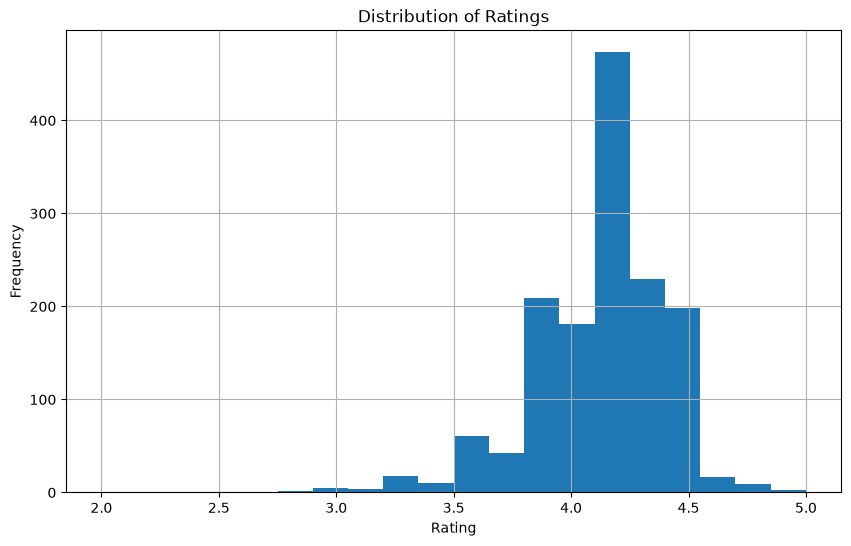

In [19]:
# Visualize the distribution of ratings across product categories

plt.figure(figsize=(10, 6))
df['rating'].hist(bins=20)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [20]:
# Because the category column contains multiple categories separated by a pipe (|), we can extract the main category by splitting the string and taking the first element.

df["main_category"] = df["category"].apply(lambda x: str(x).split("|")[0])

df["main_category"].value_counts()

main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

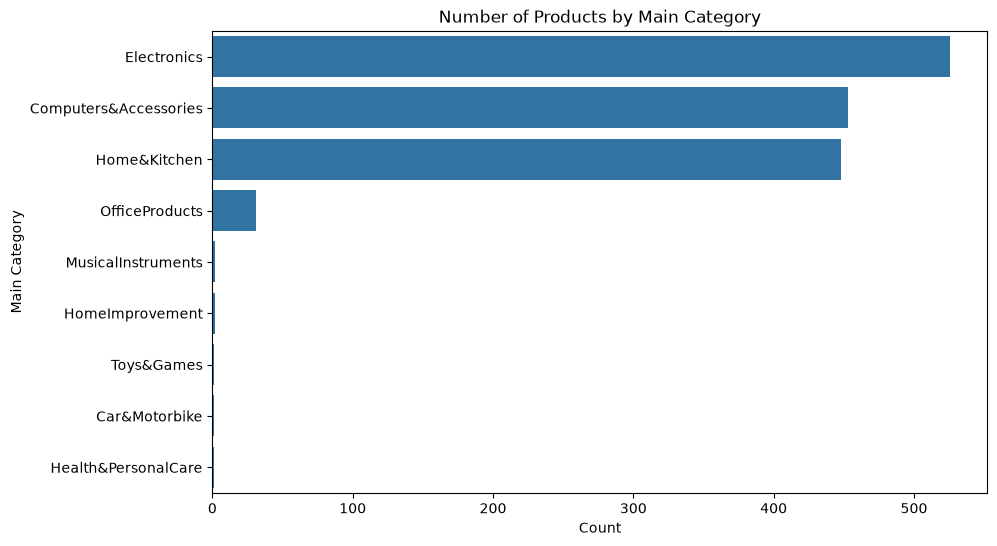

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(
    data=df,
    y="main_category",
    order=df["main_category"].value_counts().index
)
plt.title("Number of Products by Main Category")
plt.xlabel("Count")
plt.ylabel("Main Category")
plt.show()

In [22]:
category_rating = df.groupby("main_category")["rating"].mean().sort_values(ascending=False)

category_rating

main_category
OfficeProducts           4.309677
Toys&Games               4.300000
HomeImprovement          4.250000
Computers&Accessories    4.154967
Electronics              4.081749
Home&Kitchen             4.040848
Health&PersonalCare      4.000000
MusicalInstruments       3.900000
Car&Motorbike            3.800000
Name: rating, dtype: float64

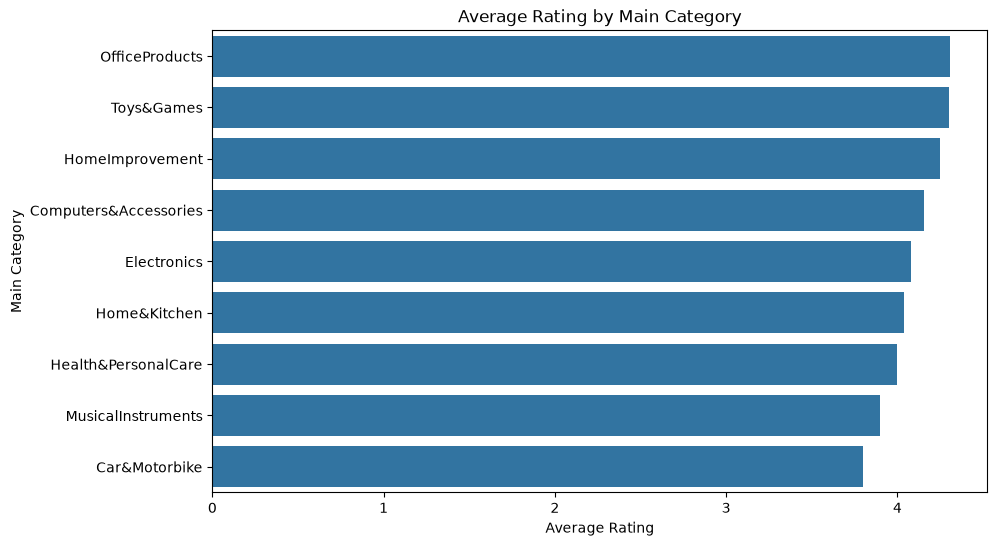

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=category_rating.values,
    y=category_rating.index
)
plt.title("Average Rating by Main Category")
plt.xlabel("Average Rating")
plt.ylabel("Main Category")
plt.show()

Customer Sentiment could not be analyzed because there is no datetime column in the dataset

## Section 2: Feature Engineering & Predictive Modeling

### 1. Feature Engineering

In [24]:
from textblob import TextBlob

In [25]:
# Create a new features - Review Length((Number of words in the review content))
df["review_length"] = df["clean_review"].apply(lambda x: len(x.split()))
df[["clean_review", "review_length"]].head()

,clean_review,review_length
0,look durable charging fine toono complainschar...,36
1,ordered cable connect phone android auto car c...,113
2,quite durable sturdy good nice productworking ...,10
3,good productlong wirecharges goodnicei bought ...,45
4,bought instead original apple work r fast appl...,238


In [26]:
# Sentiment polarity and subjectivity using TextBlob or VADER sentiment analysis

df["polarity"] = df["clean_review"].apply(lambda x: TextBlob(x).sentiment.polarity)
df[["clean_review", "polarity"]].head()

,clean_review,polarity
0,look durable charging fine toono complainschar...,0.481944
1,ordered cable connect phone android auto car c...,0.222967
2,quite durable sturdy good nice productworking ...,0.633333
3,good productlong wirecharges goodnicei bought ...,0.333333
4,bought instead original apple work r fast appl...,0.332516


In [27]:
#Price drop percentage from acual price to discounted price

df["price_drop"] = ((df["actual_price"] - df["discounted_price"]) / df["actual_price"]) * 100
df[["actual_price", "discounted_price", "price_drop"]].head()

,actual_price,discounted_price,price_drop
0,1099.0,399.0,63.694268
1,349.0,199.0,42.979943
2,1899.0,199.0,89.520800
3,699.0,329.0,52.932761
4,399.0,154.0,61.403509


In [28]:
# Encode Categorical Variables like category and user_name

from sklearn.preprocessing import LabelEncoder

category_encoder = LabelEncoder()
user_encoder = LabelEncoder()

df["category_encoded"] = category_encoder.fit_transform(df["category"])
df["user_name_encoded"] = user_encoder.fit_transform(df["user_name"])

df[["category", "category_encoded", "user_name", "user_name_encoded"]].head()

,category,category_encoded,user_name,user_name_encoded
0,Computers&Accessories|Accessories&Peripherals|...,10,"Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...",522
1,Computers&Accessories|Accessories&Peripherals|...,10,"ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...",207
2,Computers&Accessories|Accessories&Peripherals|...,10,"Kunal,Himanshu,viswanath,sai niharka,saqib mal...",482
3,Computers&Accessories|Accessories&Peripherals|...,10,"Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...",614
4,Computers&Accessories|Accessories&Peripherals|...,10,"rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...",1139


In [29]:
# Create Sentiment target variable and encoding it as rating of 3 and above as positive and rest as negative
df["sentiment"] = df["rating"].apply(lambda x: "Positive" if x >= 3 else "Negative")

sentiment_encoder = LabelEncoder()

df["sentiment_label"] = sentiment_encoder.fit_transform(df["sentiment"])

df[["rating", "sentiment", "sentiment_label"]].head()

,rating,sentiment,sentiment_label
0,4.2,Positive,1
1,4.0,Positive,1
2,3.9,Positive,1
3,4.2,Positive,1
4,4.2,Positive,1


In [30]:
df["sentiment"].value_counts()

sentiment
Positive    1459
Negative       6
Name: count, dtype: int64

In [31]:
# Use TF-IDF Vectorization to convert review_content into numerical features for machine learning models.
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["clean_review"])

y = df["sentiment_label"]

X.shape

(1465, 5000)

### 2. Sentiment Classification & Rating Prediction

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Accuracy: 0.9965870307167235
Confusion Matrix:
[[  0   1]
 [  0 292]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00       292

    accuracy                           1.00       293
   macro avg       0.50      0.50      0.50       293
weighted avg       0.99      1.00      0.99       293



c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

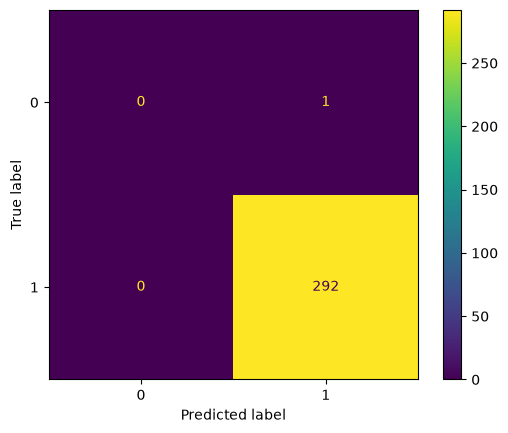

In [33]:
# Train Models : Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Initialize and train the Logistic Regression model

logreg_model = LogisticRegression(random_state=42, max_iter=1000)
logreg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log = logreg_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_log)
conf_matrix = confusion_matrix(y_test, y_pred_log)
class_report = classification_report(y_test, y_pred_log)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Display the confusion matrix
ConfusionMatrixDisplay(conf_matrix).plot()

Accuracy: 0.9897610921501706
Confusion Matrix:
[[  0   1]
 [  2 290]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.99      0.99       292

    accuracy                           0.99       293
   macro avg       0.50      0.50      0.50       293
weighted avg       0.99      0.99      0.99       293



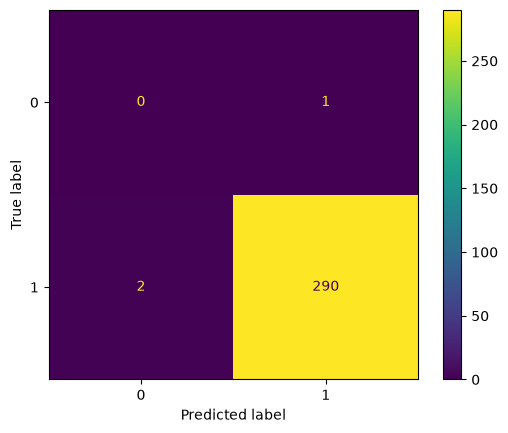

In [34]:
# Train Models : Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree Classifier model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_dt)
conf_matrix = confusion_matrix(y_test, y_pred_dt)
class_report = classification_report(y_test, y_pred_dt)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Display the confusion matrix
ConfusionMatrixDisplay(conf_matrix).plot()

Accuracy: 0.9965870307167235
Confusion Matrix:
[[  0   1]
 [  0 292]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00       292

    accuracy                           1.00       293
   macro avg       0.50      0.50      0.50       293
weighted avg       0.99      1.00      0.99       293



c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

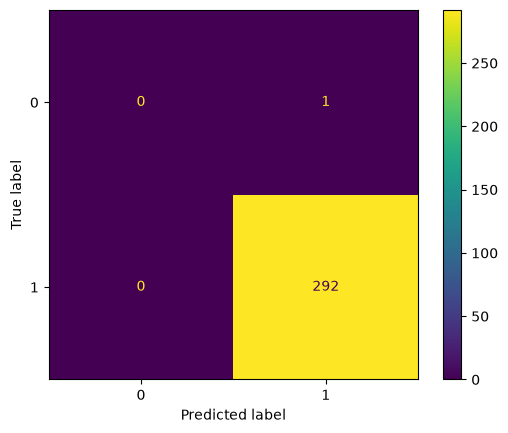

In [35]:
# Train Models : Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_rf)
conf_matrix = confusion_matrix(y_test, y_pred_rf)
class_report = classification_report(y_test, y_pred_rf)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Display the confusion matrix
ConfusionMatrixDisplay(conf_matrix).plot()

In [36]:
# Compare the performance of the three models

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.996587
2,Random Forest,0.996587
1,Decision Tree,0.989761


#### Training a Regression model to predict product ratings. This requires target variables to change to ratings.

In [37]:
X_reg = X

y_reg = df["rating"]

In [38]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print(X_train_reg.shape)
print(X_test_reg.shape)

(1172, 5000)
(293, 5000)


In [39]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

In [40]:
# Train Regression Models : Linear Regression

linear_model = LinearRegression()
linear_model.fit(X_train_reg, y_train_reg)

y_pred_reg = linear_model.predict(X_test_reg)

mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Linear Regression MSE: {mse}")
print(f"Linear Regression RMSE: {rmse}")
print(f"Linear Regression R2: {r2}")

Linear Regression MSE: 0.08401268841874146
Linear Regression RMSE: 0.2898494236991708
Linear Regression R2: -0.02886205122631047


In [41]:
# Train Models : Ridge Regression

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_reg, y_train_reg)

y_pred_ridge = ridge_model.predict(X_test_reg)

mse_ridge = mean_squared_error(y_test_reg, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test_reg, y_pred_ridge)

print(f"Ridge Regression MSE: {mse_ridge}")
print(f"Ridge Regression RMSE: {rmse_ridge}")
print(f"Ridge Regression R2: {r2_ridge}")

Ridge Regression MSE: 0.06356271185873404
Ridge Regression RMSE: 0.25211646487037304
Ridge Regression R2: 0.22157874797998633


In [42]:
# Train Models : Lasso Regression

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_reg, y_train_reg)

y_pred_lasso = lasso_model.predict(X_test_reg)

mse_lasso = mean_squared_error(y_test_reg, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test_reg, y_pred_lasso)

print(f"Lasso Regression MSE: {mse_lasso}")
print(f"Lasso Regression RMSE: {rmse_lasso}")
print(f"Lasso Regression R2: {r2_lasso}")

Lasso Regression MSE: 0.08207527169798136
Lasso Regression RMSE: 0.2864878212035921
Lasso Regression R2: -0.005135462077465736


In [43]:
results_reg = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MSE" : [
        mean_squared_error(y_test_reg, y_pred_reg),
        mean_squared_error(y_test_reg, y_pred_ridge),
        mean_squared_error(y_test_reg, y_pred_lasso)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)),
        np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test_reg, y_pred_lasso))
    ],
    "R2 Score": [
        r2_score(y_test_reg, y_pred_reg),
        r2_score(y_test_reg, y_pred_ridge),
        r2_score(y_test_reg, y_pred_lasso)
    ]
})

results_reg

,Model,MSE,RMSE,R2 Score
0,Linear Regression,0.084013,0.289849,-0.028862
1,Ridge Regression,0.063563,0.252116,0.221579
2,Lasso Regression,0.082075,0.286488,-0.005135


## Section 3: Deep Learning & NLP for Review Analysis

### Deep Learning-Based Sentiment Analysis

In [44]:
# Implement a LSTM to analyze review text data. We will use Keras and TensorFlow to build and train the LSTM model.
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_text = df["clean_review"]
y = df["sentiment_label"]

# Train-test split for LSTM model
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Tokenize the text data
vocab_size = 5000
embedding_dim = 64
max_length = 100
oov_tok = "<OOV>"

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token=oov_tok
)

tokenizer.fit_on_texts(X_train_text)

word_index = tokenizer.word_index

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences to ensure uniform input size
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)


In [45]:
# LSTM Model Building

lstm_model = tf.keras.Sequential([

    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),

    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

lstm_model.summary()

c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Compile the LSTM model
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [47]:
# Train the LSTM model
history = lstm_model.fit(
    X_train_pad,
    y_train_text,
    validation_data=(X_test_pad, y_test_text),
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9855 - loss: 0.1898 - val_accuracy: 0.9966 - val_loss: 0.0324
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9957 - loss: 0.0362 - val_accuracy: 0.9966 - val_loss: 0.0233
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9957 - loss: 0.0283 - val_accuracy: 0.9966 - val_loss: 0.0230
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9957 - loss: 0.0281 - val_accuracy: 0.9966 - val_loss: 0.0228
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9957 - loss: 0.0278 - val_accuracy: 0.9966 - val_loss: 0.0228
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9957 - loss: 0.0284 - val_accuracy: 0.9966 - val_loss: 0.0225
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9957 - loss: 0.0275 - val_accuracy: 0.9966 - val_loss: 0.0225
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9957 - loss: 0.0269 - val_accuracy: 0.9966 - v

In [48]:
# Evaluate the LSTM model
loss, accuracy = lstm_model.evaluate(X_test_pad, y_test_text)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9966 - loss: 0.0207
Test Loss: 0.020737191662192345
Test Accuracy: 0.9965870380401611


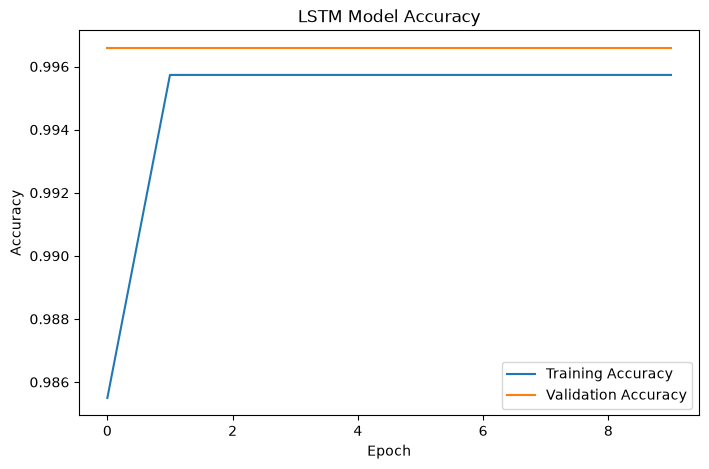

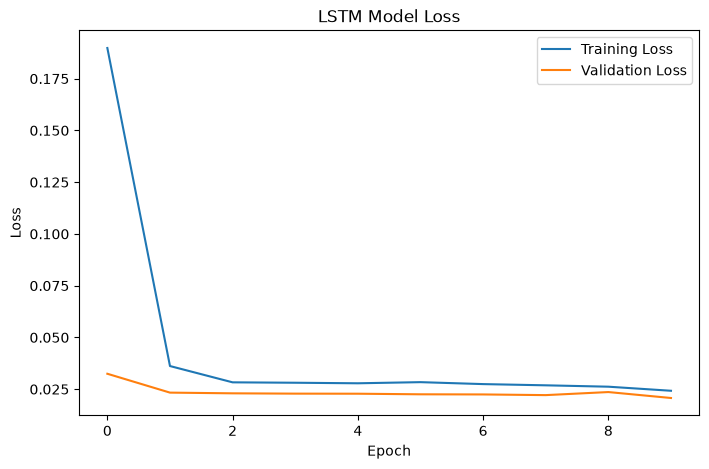

In [49]:
# Plot training and validation accuracy and loss

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("LSTM Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [50]:
# Make Predictions with the LSTM model

y_pred_prob = lstm_model.predict(X_test_pad)

y_pred = (y_pred_prob > 0.5).astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [51]:
# Evaluate Predictions


print("Confusion Matrix:")
print(confusion_matrix(y_test_text, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_text, y_pred))

Confusion Matrix:
[[  0   1]
 [  0 292]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00       292

    accuracy                           1.00       293
   macro avg       0.50      0.50      0.50       293
weighted avg       0.99      1.00      0.99       293



c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

The LSTM model achieved very high accuracy; however, the confusion matrix shows that the test set was highly imbalanced, with very few negative reviews. Therefore, accuracy alone may not fully represent the model’s ability to detect negative sentiment.

### Summarizing Customer Reviews

In [52]:
# import transformers
# import torch

In [53]:
# implement Transformer models to generate summaries - BART

# from transformers import pipeline

# summarizer = pipeline(
#     "summarization",
#     model="facebook/bart-large-cnn",
#     framework="pt"
# )

In [54]:
# !pip install openai

In [59]:
import os
from openai import OpenAI
from dotenv import load_dotenv

In [60]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

In [61]:
# Create a Summarization Function - Open AI API

def openai_summarize_reviews(text):

    prompt = f"""
    Summarize the following customer product reviews in 3-4 concise sentences.
    Focus on product quality, usability, common complaints, and overall customer sentiment.

    Reviews:
    {text}
    """

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "You summarize customer product reviews clearly and concisely."},
            {"role": "user", "content": prompt}
        ],
        temperature=0.3
    )

    return response.choices[0].message.content

## Section 4: LLM Integration & Deployment

In [62]:
import gradio as gr

c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [63]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hskim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hskim\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [64]:
def extractive_summarize_reviews(text, top_n=3):

    text = str(text)
    sentences = sent_tokenize(text)

    if len(sentences) <= top_n:
        return text

    vectorizer = TfidfVectorizer(stop_words="english")
    sentence_vectors = vectorizer.fit_transform(sentences)

    sentence_scores = np.array(sentence_vectors.sum(axis=1)).flatten()

    top_sentence_indices = sentence_scores.argsort()[-top_n:]
    top_sentence_indices = sorted(top_sentence_indices)

    summary = " ".join([sentences[i] for i in top_sentence_indices])

    return summary

In [65]:
# Develop a Gradio-based web app where users can input multile reviews separated by a pipe (|) and the app will generate a summary of the reviews using the BART model.

def review_app(user_reviews, summary_method):

    try:

        reviews_list = user_reviews.split("|")
        combined_reviews = " ".join(reviews_list).strip()

        print("Step 1: Input received")

        
        if summary_method == "Extractive":
            summary = extractive_summarize_reviews(combined_reviews)
        else:
            summary = openai_summarize_reviews(combined_reviews)

        print("Step 2: Summary generated")

        
        # LSTM Prediction
        cleaned_text = clean_text(combined_reviews)

        sequence = tokenizer.texts_to_sequences([cleaned_text])

        padded = pad_sequences(
            sequence,
            maxlen=max_length,
            padding="post",
            truncating="post"
        )

        prediction = lstm_model.predict(padded)

        sentiment = (
            "Positive"
            if prediction[0][0] >= 0.5
            else "Negative"
        )

        print("Step 3: Sentiment predicted")

        return summary, sentiment

    except Exception as e:
        import traceback

        traceback.print_exc()

        return str(e), str(e)

In [ ]:
app = gr.Interface(
    fn=review_app,
    inputs=[
        gr.Textbox(
            lines=8,
            placeholder="Enter multiple reviews separated by |",
            label="Customer Reviews"
        ),
        gr.Dropdown(
            choices=["Extractive", "Abstractive"],
            value="Extractive",
            label="Summarization Method"
        )
    ],
    outputs=[
        gr.Textbox(label="Generated Summary"),
        gr.Textbox(label="Predicted Sentiment")
    ],
    title="Product Review Summarization App",
    description="Enter multiple product reviews separated by (|). Choose Extractive summarization using TF-IDF or Abstractive summarization using an OpenAI LLM."
)

app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Step 1: Input received
Step 2: Summary generated
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Step 3: Sentiment predicted


c:\Users\hskim\anaconda3\envs\tfdk\Lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Step 1: Input received
Step 2: Summary generated
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Step 3: Sentiment predicted
